# CriticalGraphRAG — Evaluación de KPIs (Incremento 04)

**ITBA — Ciencia de Datos Aplicada**

Notebook autónomo que valida sobre la API deployada los KPIs definidos en el Incremento 01.

**API:** `https://critigal-graph-rag.onrender.com/chat`

## KPIs a validar

| # | KPI | Umbral |
|---|-----|--------|
| 1 | Exactitud factual sobre subset de evaluación | **≥ 80%** |
| 2 | Tasa de alucinación en respuestas generadas | **< 20%** |
| 3 | Tiempo de respuesta promedio por consulta | **< 5 s** |

## Estrategia

Subset curado de **9 preguntas** (3 por cada tool del agente) con ground truth derivada de Cypher contra el Knowledge Graph. Una sola pasada por la API mide simultáneamente accuracy, alucinación y latencia. Scoring inline — el notebook no depende de scripts externos.

## 1. Setup

In [57]:
from __future__ import annotations

import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display, Markdown

API_BASE = "https://critigal-graph-rag.onrender.com"
CHAT_URL = f"{API_BASE}/chat"
HEALTH_URL = f"{API_BASE}/health"
TIMEOUT_S = 120


def ask(question: str) -> tuple[str, float, str]:
    """Llama a la API; devuelve (respuesta, latencia_ms, error)."""
    t0 = time.monotonic()
    try:
        r = requests.post(CHAT_URL, json={"message": question}, timeout=TIMEOUT_S)
        r.raise_for_status()
        latency_ms = (time.monotonic() - t0) * 1000
        return r.json()["response"], latency_ms, ""
    except Exception as exc:
        latency_ms = (time.monotonic() - t0) * 1000
        return "", latency_ms, str(exc)


# Warmup — Render free tier puede dormir el contenedor; evita sesgar la latencia.
try:
    requests.get(HEALTH_URL, timeout=30)
    print("API warmup OK")
except Exception as exc:
    print(f"Warmup falló (continuamos): {exc}")

API warmup OK


## 2. Subset de evaluación

9 preguntas balanceadas (3 por tool). Las ground truth de las preguntas factuales fueron derivadas de queries Cypher validadas contra Neo4j (`tests/gold_cypher.yaml`). Para las preguntas descriptivas (`similarity_search`) la ground truth es un conjunto de keywords que deberían aparecer en una respuesta correcta — el scoring usa Jaccard sobre tokens.

In [58]:
SUBSET = [
    # --- cypher_query (3) — preguntas factuales con query predefinida ---
    {
        "id": "cq1",
        "tool_target": "cypher_query",
        "tipo": "factual_numeric",
        "pregunta": "¿Cuántos eventos registró ACLED en Israel durante octubre de 2023?",
        "expected": "768",
    },
    {
        "id": "cq2",
        "tool_target": "cypher_query",
        "tipo": "factual_numeric",
        "pregunta": "¿Cuántas fatalidades totales se registraron en Israel durante 2023?",
        "expected": "1773",
    },
    {
        "id": "cq3",
        "tool_target": "cypher_query",
        "tipo": "factual_numeric",
        "pregunta": "¿Cuántos eventos registró ACLED en el distrito de Tel Aviv durante todo el año 2023?",
        "expected": "610",
    },
    # --- text2cypher (3) — sin query predefinida, el LLM genera Cypher dinámico ---
    {
        "id": "t2c1",
        "tool_target": "text2cypher",
        "tipo": "factual_numeric",
        "pregunta": "¿Cuántos eventos registró ACLED en el distrito de Jerusalén durante 2023?",
        "expected": "280",
    },
    {
        "id": "t2c2",
        "tool_target": "text2cypher",
        "tipo": "factual_numeric",
        "pregunta": "¿Cuántos eventos de tipo 'Battles' (primario) se registraron en Israel en 2023?",
        "expected": "167",
    },
    {
        "id": "t2c3",
        "tool_target": "text2cypher",
        "tipo": "factual_numeric",
        "pregunta": "¿Cuántos eventos más ocurrieron en Israel en octubre de 2023 respecto a septiembre de 2023?",
        "expected": "588",
    },
    # --- similarity_search (3) — preguntas descriptivas; expected = keywords clave ---
    {
        "id": "ss1",
        "tool_target": "similarity_search",
        "tipo": "descriptive",
        "pregunta": "¿Cómo se describen los ataques con cohetes registrados en Israel en 2023?",
        "expected": "cohetes Hamas Gaza Sderot Ashkelon disparados Israel",
    },
    {
        "id": "ss2",
        "tool_target": "similarity_search",
        "tipo": "descriptive",
        "pregunta": "Describí incidentes que ocurrieron en zonas fronterizas con Líbano",
        "expected": "Hezbollah frontera norte Líbano antitanque cohetes HaZafon",
    },
    {
        "id": "ss3",
        "tool_target": "similarity_search",
        "tipo": "descriptive",
        "pregunta": "¿Qué tipo de protestas se registraron en Tel Aviv durante 2023?",
        "expected": "protestas Tel Aviv reforma judicial manifestantes gobierno Netanyahu",
    },
]

df_subset = pd.DataFrame(SUBSET)
display(df_subset[["id", "tool_target", "tipo", "pregunta", "expected"]])

,id,tool_target,tipo,pregunta,expected
0,cq1,cypher_query,factual_numeric,¿Cuántos eventos registró ACLED en Israel dura...,768
1,cq2,cypher_query,factual_numeric,¿Cuántas fatalidades totales se registraron en...,1773
2,cq3,cypher_query,factual_numeric,¿Cuántos eventos registró ACLED en el distrito...,610
3,t2c1,text2cypher,factual_numeric,¿Cuántos eventos registró ACLED en el distrito...,280
4,t2c2,text2cypher,factual_numeric,¿Cuántos eventos de tipo 'Battles' (primario) ...,167
5,t2c3,text2cypher,factual_numeric,¿Cuántos eventos más ocurrieron en Israel en o...,588
6,ss1,similarity_search,descriptive,¿Cómo se describen los ataques con cohetes reg...,cohetes Hamas Gaza Sderot Ashkelon disparados ...
7,ss2,similarity_search,descriptive,Describí incidentes que ocurrieron en zonas fr...,Hezbollah frontera norte Líbano antitanque coh...
8,ss3,similarity_search,descriptive,¿Qué tipo de protestas se registraron en Tel A...,protestas Tel Aviv reforma judicial manifestan...


## 3. Scoring inline

Dos métodos según el tipo de pregunta:

- **`numeric_match`** (factuales): extrae todos los números de la respuesta y compara el más cercano al expected. Tolerancia ±5% (score = 1.0); error mayor reduce el score linealmente.
- **`keyword_recall`** (descriptivas): fracción de keywords esperadas presentes en la respuesta. `recall = |expected ∩ pred| / |expected|`. Normaliza acentos y mayúsculas. No penaliza respuestas verbosas (a diferencia de Jaccard, que sí lo hace porque infla la unión).

**Umbral de alucinación:**

| Método | Umbral `hallucinated` |
|--------|-----------------------|
| `numeric_match`  | score < 0.5 (>50% de error sobre el valor real) |
| `keyword_recall` | score < 0.4 (menos del 40% de keywords presentes) |

In [59]:
from __future__ import annotations

import unicodedata


def extract_numbers(text: str) -> list[float]:
    """Extrae TODOS los números (enteros, decimales, con separadores de miles) del texto."""
    out: list[float] = []
    for raw in re.findall(r"-?\d{1,3}(?:[.,]\d{3})+(?:[.,]\d+)?|-?\d+(?:[.,]\d+)?", text or ""):
        s = raw
        if "." in s and "," in s:
            # ambos presentes → asumir formato ES: '.' miles, ',' decimal
            s = s.replace(".", "").replace(",", ".")
        elif "," in s:
            # solo coma: si parece decimal (1-2 dígitos después) tratarla como tal; si no, miles
            tail = s.split(",")[-1]
            s = s.replace(",", ".") if len(tail) <= 2 else s.replace(",", "")
        try:
            out.append(float(s))
        except ValueError:
            continue
    return out


def best_number_match(expected: float, candidates: list[float]) -> float | None:
    """Candidato con menor error relativo respecto a `expected`. None si no hay candidatos."""
    if not candidates:
        return None
    if expected == 0:
        return min(candidates, key=abs)
    return min(candidates, key=lambda x: abs(x - expected) / abs(expected))


def strip_accents(text: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFD", text) if unicodedata.category(c) != "Mn")


def tokenize(text: str) -> set[str]:
    text = strip_accents((text or "").lower())
    return {t for t in re.split(r"[^\w]+", text) if t and len(t) > 2}


def score_response(pred: str, expected: str, tipo: str) -> dict:
    """Devuelve {method, score, hallucinated, best_num}."""
    pred, expected = (pred or "").strip(), (expected or "").strip()

    if tipo == "factual_numeric":
        exp_nums = extract_numbers(expected)
        if not exp_nums:
            return {"method": "numeric_match", "score": 0.0, "hallucinated": True, "best_num": None}
        exp_n = exp_nums[0]
        candidates = extract_numbers(pred)
        best = best_number_match(exp_n, candidates)
        if best is None:
            return {"method": "numeric_match", "score": 0.0, "hallucinated": True, "best_num": None}
        if exp_n == 0:
            score = 1.0 if best == 0 else 0.0
        else:
            err = abs(best - exp_n) / abs(exp_n)
            score = 1.0 if err <= 0.05 else max(0.0, 1.0 - err)
        return {"method": "numeric_match", "score": float(score),
                "hallucinated": score < 0.5, "best_num": best}

    # descriptive → recall sobre keywords esperadas
    exp_t, pred_t = tokenize(expected), tokenize(pred)
    if not exp_t:
        return {"method": "keyword_recall", "score": 0.0, "hallucinated": True, "best_num": None}
    recall = len(exp_t & pred_t) / len(exp_t)
    return {"method": "keyword_recall", "score": float(recall),
            "hallucinated": recall < 0.4, "best_num": None}

## 4. Evaluación contra la API

Loop sobre el subset, **3 iteraciones por pregunta** (27 calls totales). Las iteraciones múltiples capturan la varianza propia del LLM (no determinístico) y permiten reportar mean ± std por pregunta y por KPI.

In [60]:
N_RUNS = 5

# Consultas a la API — solo recolecta response + latencia, sin scoring.
api_results = []
total = len(SUBSET) * N_RUNS
i = 0
for run in range(1, N_RUNS + 1):
    for item in SUBSET:
        i += 1
        print(f"[{i}/{total}] run={run} id={item['id']} — {item['pregunta'][:60]}...")
        response, latency_ms, error = ask(item["pregunta"])
        api_results.append({
            "run": run,
            "id": item["id"],
            "tool_target": item["tool_target"],
            "tipo": item["tipo"],
            "pregunta": item["pregunta"],
            "expected": item["expected"],
            "response": response,
            "latency_ms": round(latency_ms, 1),
            "error": error,
        })

responses_df = pd.DataFrame(api_results)
print(f"\n{len(responses_df)} respuestas recolectadas.")

[1/45] run=1 id=cq1 — ¿Cuántos eventos registró ACLED en Israel durante octubre de...
[2/45] run=1 id=cq2 — ¿Cuántas fatalidades totales se registraron en Israel durant...
[3/45] run=1 id=cq3 — ¿Cuántos eventos registró ACLED en el distrito de Tel Aviv d...
[4/45] run=1 id=t2c1 — ¿Cuántos eventos registró ACLED en el distrito de Jerusalén ...
[5/45] run=1 id=t2c2 — ¿Cuántos eventos de tipo 'Battles' (primario) se registraron...
[6/45] run=1 id=t2c3 — ¿Cuántos eventos más ocurrieron en Israel en octubre de 2023...
[7/45] run=1 id=ss1 — ¿Cómo se describen los ataques con cohetes registrados en Is...
[8/45] run=1 id=ss2 — Describí incidentes que ocurrieron en zonas fronterizas con ...
[9/45] run=1 id=ss3 — ¿Qué tipo de protestas se registraron en Tel Aviv durante 20...
[10/45] run=2 id=cq1 — ¿Cuántos eventos registró ACLED en Israel durante octubre de...
[11/45] run=2 id=cq2 — ¿Cuántas fatalidades totales se registraron en Israel durant...
[12/45] run=2 id=cq3 — ¿Cuántos eventos registró 

In [61]:
# Cálculo de scores sobre las respuestas — se puede re-ejecutar sin volver a llamar a la API.
scored = []
for r in responses_df.to_dict("records"):
    s = score_response(r["response"], r["expected"], r["tipo"])
    scored.append({
        **r,
        "score": s["score"],
        "score_method": s["method"],
        "hallucinated": s["hallucinated"],
        "best_num": s["best_num"],
    })

raw_df = pd.DataFrame(scored)

# Agregado por pregunta — mean/std a través de las 3 corridas
agg_df = raw_df.groupby(["id", "tool_target", "tipo"], as_index=False).agg(
    score_mean=("score", "mean"),
    score_std=("score", "std"),
    latency_mean_ms=("latency_ms", "mean"),
    latency_std_ms=("latency_ms", "std"),
    hallucination_rate=("hallucinated", "mean"),
    n_runs=("score", "count"),
)

# Tabla cruda: pregunta + esperado vs obtenido + latencia + score por iteración
print(f"Resultados crudos ({len(raw_df)} filas):")
raw_show = raw_df[["run", "id", "tool_target", "pregunta", "expected", "response",
                   "latency_ms", "score", "hallucinated"]].copy()
raw_show["pregunta"] = raw_show["pregunta"].str.slice(0, 80) + "…"
raw_show["response"] = raw_show["response"].fillna("").str.slice(0, 150)
display(raw_show.style.format({"score": "{:.2f}", "latency_ms": "{:.0f}"}))

Resultados crudos (45 filas):


,run,id,tool_target,pregunta,expected,response,latency_ms,score,hallucinated
0,1,cq1,cypher_query,¿Cuántos eventos registró ACLED en Israel durante octubre de 2023?…,768,ACLED registró 768 eventos en Israel durante octubre de 2023.,2456,1.00,False
1,1,cq2,cypher_query,¿Cuántas fatalidades totales se registraron en Israel durante 2023?…,1773,Se registraron un total de 1773 fatalidades en Israel durante 2023.,2447,1.00,False
2,1,cq3,cypher_query,¿Cuántos eventos registró ACLED en el distrito de Tel Aviv durante todo el año 2…,610,ACLED registró 610 eventos en el distrito de Tel Aviv durante todo el año 2023.,2455,1.00,False
3,1,t2c1,text2cypher,¿Cuántos eventos registró ACLED en el distrito de Jerusalén durante 2023?…,280,ACLED registró 280 eventos en el distrito de Jerusalén durante 2023.,10340,1.00,False
4,1,t2c2,text2cypher,¿Cuántos eventos de tipo 'Battles' (primario) se registraron en Israel en 2023?…,167,Se registraron 167 eventos de tipo 'Battles' en Israel en 2023.,3684,1.00,False
5,1,t2c3,text2cypher,¿Cuántos eventos más ocurrieron en Israel en octubre de 2023 respecto a septiemb…,588,En octubre de 2023 ocurrieron 588 eventos más en Israel respecto a septiembre de 2023.,3155,1.00,False
6,1,ss1,similarity_search,¿Cómo se describen los ataques con cohetes registrados en Israel en 2023?…,cohetes Hamas Gaza Sderot Ashkelon disparados Israel,Los ataques con cohetes registrados en Israel en 2023 se describen de la siguiente manera: * **Perpetradores y Origen:** Fueron lanzados por el PIJ,9710,0.57,False
7,1,ss2,similarity_search,Describí incidentes que ocurrieron en zonas fronterizas con Líbano…,Hezbollah frontera norte Líbano antitanque cohetes HaZafon,"Aquí tienes una descripción de los incidentes ocurridos en zonas fronterizas con Líbano, según los datos disponibles: * **21 de marzo de 2023:** Do",6391,0.57,False
8,1,ss3,similarity_search,¿Qué tipo de protestas se registraron en Tel Aviv durante 2023?…,protestas Tel Aviv reforma judicial manifestantes gobierno Netanyahu,"En Tel Aviv durante 2023, se registraron los siguientes tipos de protestas: * Protesta pacífica * Protesta con intervención * Fuerza excesiva c",8382,0.50,False
9,2,cq1,cypher_query,¿Cuántos eventos registró ACLED en Israel durante octubre de 2023?…,768,ACLED registró 768 eventos en Israel durante octubre de 2023.,3178,1.00,False


## 5. Cómputo de KPIs

In [62]:
import numpy as np

# KPI por corrida: agrega las 9 preguntas dentro de cada run, después promedia.
# accuracy_run = % preguntas no alucinadas en ese run.
per_run = raw_df.groupby("run").agg(
    accuracy=("hallucinated", lambda s: (~s).mean()),
    hallucination_rate=("hallucinated", "mean"),
    latency_avg_s=("latency_ms", lambda s: s.mean() / 1000),
)

acc_mean, acc_std = per_run["accuracy"].mean(), per_run["accuracy"].std(ddof=1)
hal_mean, hal_std = per_run["hallucination_rate"].mean(), per_run["hallucination_rate"].std(ddof=1)
lat_mean, lat_std = per_run["latency_avg_s"].mean(), per_run["latency_avg_s"].std(ddof=1)
lat_p95 = raw_df["latency_ms"].quantile(0.95) / 1000

kpis = pd.DataFrame([
    {"KPI": "Exactitud factual",
     "Valor (mean ± std)": f"{acc_mean*100:.1f}% ± {acc_std*100:.1f}%",
     "Umbral": "≥ 80%",
     "Estado": "✓" if acc_mean >= 0.80 else "✗"},
    {"KPI": "Tasa de alucinación",
     "Valor (mean ± std)": f"{hal_mean*100:.1f}% ± {hal_std*100:.1f}%",
     "Umbral": "< 20%",
     "Estado": "✓" if hal_mean < 0.20 else "✗"},
    {"KPI": "Latencia promedio (s)",
     "Valor (mean ± std)": f"{lat_mean:.2f} ± {lat_std:.2f}",
     "Umbral": "< 5",
     "Estado": "✓" if lat_mean < 5 else "✗"},
])
display(kpis)

print(f"\nKPI por corrida (n={len(per_run)}):")
display(per_run.style.format({"accuracy": "{:.3f}", "hallucination_rate": "{:.3f}", "latency_avg_s": "{:.2f}"}))
print(f"\nLatencia p95 global: {lat_p95:.2f}s (informativo)")

,KPI,Valor (mean ± std),Umbral,Estado
0,Exactitud factual,91.1% ± 5.0%,≥ 80%,✓
1,Tasa de alucinación,8.9% ± 5.0%,< 20%,✓
2,Latencia promedio (s),4.57 ± 0.58,< 5,✓



KPI por corrida (n=5):


,accuracy,hallucination_rate,latency_avg_s
run,,,
1,1.000,0.000,5.45
2,0.889,0.111,4.36
3,0.889,0.111,3.83
4,0.889,0.111,4.68
5,0.889,0.111,4.56



Latencia p95 global: 10.21s (informativo)


## 6. Dashboard

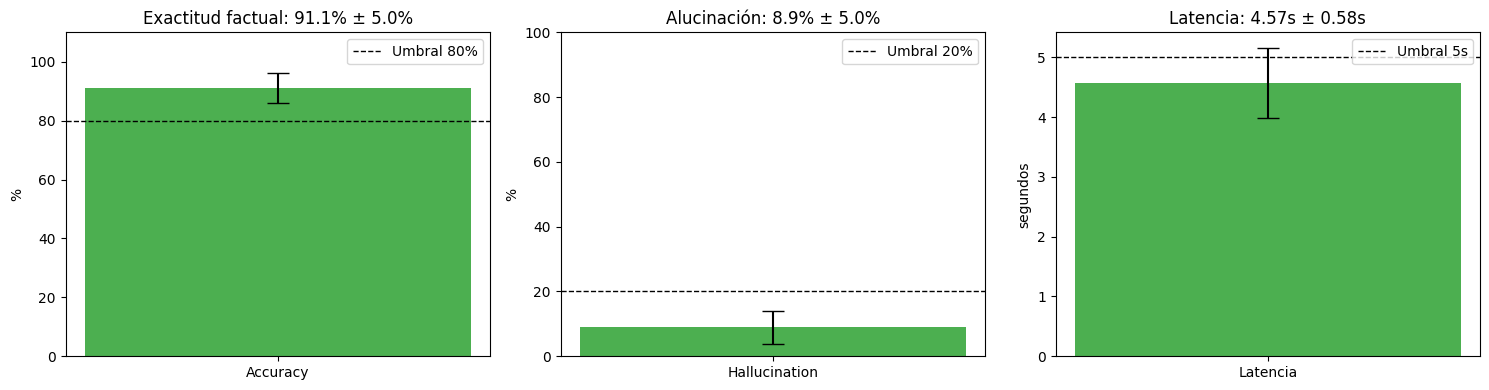

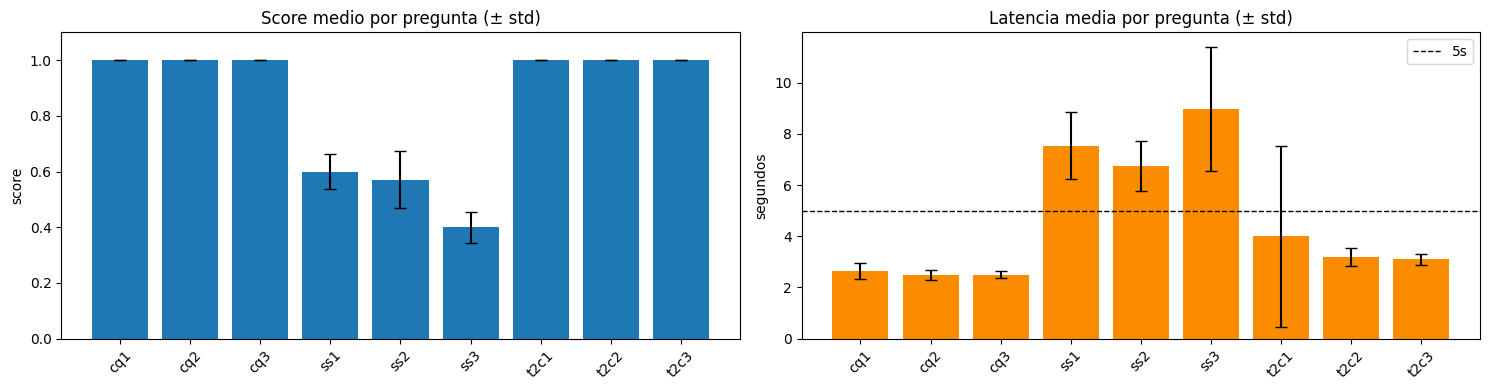

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# KPI 1: Accuracy
ax = axes[0]
ax.bar(["Accuracy"], [acc_mean * 100],
       yerr=[acc_std * 100], capsize=8,
       color="#4CAF50" if acc_mean >= 0.80 else "#E53935")
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="Umbral 80%")
ax.set_ylim(0, 110)
ax.set_ylabel("%")
ax.set_title(f"Exactitud factual: {acc_mean*100:.1f}% ± {acc_std*100:.1f}%")
ax.legend()

# KPI 2: Hallucination
ax = axes[1]
ax.bar(["Hallucination"], [hal_mean * 100],
       yerr=[hal_std * 100], capsize=8,
       color="#4CAF50" if hal_mean < 0.20 else "#E53935")
ax.axhline(20, color="black", linestyle="--", linewidth=1, label="Umbral 20%")
ax.set_ylim(0, 100)
ax.set_ylabel("%")
ax.set_title(f"Alucinación: {hal_mean*100:.1f}% ± {hal_std*100:.1f}%")
ax.legend()

# KPI 3: Latency
ax = axes[2]
ax.bar(["Latencia"], [lat_mean],
       yerr=[lat_std], capsize=8,
       color="#4CAF50" if lat_mean < 5 else "#E53935")
ax.axhline(5, color="black", linestyle="--", linewidth=1, label="Umbral 5s")
ax.set_ylabel("segundos")
ax.set_title(f"Latencia: {lat_mean:.2f}s ± {lat_std:.2f}s")
ax.legend()

plt.tight_layout()
plt.show()

# Bonus: score y latencia por pregunta con barras de error
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
order = agg_df["id"].tolist()

axes[0].bar(order, agg_df["score_mean"], yerr=agg_df["score_std"].fillna(0), capsize=4)
axes[0].set_title("Score medio por pregunta (± std)")
axes[0].set_ylabel("score")
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(order, agg_df["latency_mean_ms"] / 1000,
            yerr=(agg_df["latency_std_ms"] / 1000).fillna(0), capsize=4, color="#FB8C00")
axes[1].axhline(5, color="black", linestyle="--", linewidth=1, label="5s")
axes[1].set_title("Latencia media por pregunta (± std)")
axes[1].set_ylabel("segundos")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Detalle por pregunta

In [64]:
print("Agregado por pregunta (mean ± std sobre 3 corridas):")
display(
    agg_df.style.format({
        "score_mean": "{:.2f}",
        "score_std": "{:.2f}",
        "latency_mean_ms": "{:.0f}",
        "latency_std_ms": "{:.0f}",
        "hallucination_rate": "{:.2f}",
    })
)

by_tool = raw_df.groupby("tool_target").agg(
    n=("id", "count"),
    accuracy=("hallucinated", lambda s: (~s).mean()),
    hallucination_rate=("hallucinated", "mean"),
    latency_mean_ms=("latency_ms", "mean"),
    latency_std_ms=("latency_ms", "std"),
).round(3)
print("\nAgregado por tool:")
display(by_tool)

Agregado por pregunta (mean ± std sobre 3 corridas):


,id,tool_target,tipo,score_mean,score_std,latency_mean_ms,latency_std_ms,hallucination_rate,n_runs
0,cq1,cypher_query,factual_numeric,1.00,0.00,2633,319,0.00,5
1,cq2,cypher_query,factual_numeric,1.00,0.00,2482,193,0.00,5
2,cq3,cypher_query,factual_numeric,1.00,0.00,2496,140,0.00,5
3,ss1,similarity_search,descriptive,0.60,0.06,7542,1314,0.00,5
4,ss2,similarity_search,descriptive,0.57,0.10,6748,994,0.00,5
5,ss3,similarity_search,descriptive,0.40,0.06,8972,2427,0.80,5
6,t2c1,text2cypher,factual_numeric,1.00,0.00,3992,3550,0.00,5
7,t2c2,text2cypher,factual_numeric,1.00,0.00,3207,353,0.00,5
8,t2c3,text2cypher,factual_numeric,1.00,0.00,3095,205,0.00,5



Agregado por tool:


,n,accuracy,hallucination_rate,latency_mean_ms,latency_std_ms
tool_target,,,,,
cypher_query,15,1.000,0.000,2536.667,224.073
similarity_search,15,0.733,0.267,7754.067,1834.539
text2cypher,15,1.000,0.000,3431.393,1954.116


## 8. Inspección cualitativa (preguntas + respuestas)

Para revisión manual de los casos limítrofes.

In [65]:
for qid in agg_df["id"]:
    qrows = raw_df[raw_df["id"] == qid].sort_values("run")
    first = qrows.iloc[0]
    agg = agg_df[agg_df["id"] == qid].iloc[0]
    display(Markdown(
        f"### {qid} — {first['tool_target']}\n\n"
        f"**Pregunta:** {first['pregunta']}\n\n"
        f"**Esperado:** `{first['expected']}`\n\n"
        f"**Score medio:** {agg['score_mean']:.2f} ± {agg['score_std']:.2f}  |  "
        f"**Latencia:** {agg['latency_mean_ms']:.0f}ms ± {agg['latency_std_ms']:.0f}ms  |  "
        f"**Hallu rate:** {agg['hallucination_rate']:.2f}"
    ))
    for _, r in qrows.iterrows():
        flag = "✗" if r["hallucinated"] else "✓"
        resp = r["response"] or f"(error: {r['error']})"
        display(Markdown(
            f"- **Run {r['run']}** {flag} score={r['score']:.2f} | {r['latency_ms']:.0f}ms\n\n"
            f"  > {resp}"
        ))

### cq1 — cypher_query

**Pregunta:** ¿Cuántos eventos registró ACLED en Israel durante octubre de 2023?

**Esperado:** `768`

**Score medio:** 1.00 ± 0.00  |  **Latencia:** 2633ms ± 319ms  |  **Hallu rate:** 0.00

- **Run 1** ✓ score=1.00 | 2456ms

  > ACLED registró 768 eventos en Israel durante octubre de 2023.

- **Run 2** ✓ score=1.00 | 3178ms

  > ACLED registró 768 eventos en Israel durante octubre de 2023.

- **Run 3** ✓ score=1.00 | 2451ms

  > ACLED registró 768 eventos en Israel durante octubre de 2023.

- **Run 4** ✓ score=1.00 | 2658ms

  > ACLED registró 768 eventos en Israel durante octubre de 2023.

...

- **Run 1** ✓ score=1.00 | 3155ms

  > En octubre de 2023 ocurrieron 588 eventos más en Israel respecto a septiembre de 2023.

- **Run 2** ✓ score=1.00 | 3234ms

  > En octubre de 2023, ocurrieron 588 eventos más en Israel que en septiembre de 2023.

- **Run 3** ✓ score=1.00 | 3069ms

  > En octubre de 2023, ocurrieron 588 eventos más en Israel en comparación con septiembre de 2023.

- **Run 4** ✓ score=1.00 | 3264ms

  > En octubre de 2023 ocurrieron 588 eventos más en Israel que en septiembre de 2023.

- **Run 5** ✓ score=1.00 | 2754ms

  > En octubre de 2023, ocurrieron 588 eventos más en Israel que en septiembre de 2023.